## Подготовка данных с использованием фреймворка Apache Spark

Подключим необходимые библиотеки.

In [47]:
import os
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.sql.functions import (
    regexp_replace,
    regexp_extract_all,
    regexp_extract,
    col,
    lit,
    when,
    to_date,
    from_unixtime,
    split,
    trim,
    year,
    udf, 
    array,
    expr,
    mean,
    stddev,
    corr,
    count
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.sql import functions as F
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.types import DoubleType
from pyspark.ml.stat import Correlation
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.types import DoubleType

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """

    conf = SparkConf()
    conf.setAppName("Load_DP")
    conf.setMaster("local[*]")
    conf.set("spark.driver.memory", "10g")           
    conf.set("spark.executor.memory", "15g")         
    conf.set("spark.memory.fraction", "0.8")        
    conf.set("spark.memory.storageFraction", "0.3") 
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

Для исследования будем использовать датасет, расположенный по адресу https://ods.ai/competitions/dl-fintech-bki/data.

Указываем путь.

In [5]:
database_name = "database"
path_features = f"{database_name}/train_features"

Заполняем датафрейм данными из файла.

In [6]:
train_features = spark.read.parquet(path_features)

Выводим фрагмент датафрейма на экран.

In [7]:
train_features.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

,id,features,flag,classWeight
0,3,"(294,[0,4,5,8,9,12,13,16,17,20,21,24,25,28,29,32,33,36,37,40,41,44,45,48,49,52,53,56,57,60,61,64,65,68,69,72,73,76,77,80,81,84,85,88,89,92,93,96,97,100,107,108,114,115,116,117,122,126,127,128,129,131,132,133,134,135,136,137,139,140,141,142,143,145,146,147,148,149,150,151,153,154,155,156,157,158,159,161,162,163,164,165,166,167,168,169,171,172,173,174,175,176,177,179,180,181,182,183,184,185,187,188,189,190,191,192,193,195,196,197,198,199,200,201,203,204,205,210,211,214,215,216,219,221,222,223,225,226,227,228,229,230,231,232,235,237,238,239,240,243,245,246,247,248,251,253,254,255,256,259,261,262,263,264,267,269,270,271,272,273,275,276,277,278,279,280,281,283,285,286,287,288,289,291,293],[15.0,14.0,1.0,14.0,1.0,14.0,1.0,14.0,1.0,14.0,1.0,13.0,2.0,13.0,2.0,13.0,2.0,12.0,3.0,6.0,9.0,6.0,9.0,6.0,9.0,7.0,8.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,10.0,5.0,15.0,8.0,7.0,9.0,4.0,1.0,1.0,15.0,8.0,15.0,1.0,4.47213595499958,15.0,14.0,8.0,7.0,18.0,1.0,5.424810727442149,15.0,-1.0,6.0,7.333333333333333,16.0,4.5303211281110665,0.06666666666666667,15.0,-5.0,9.0,7.6,16.0,5.803939548764639,0.06666666666666667,15.0,-7.0,4.0,7.8,16.0,4.459340117743239,0.13333333333333333,15.0,10.0,8.0,5.2,16.0,1.0,4.7539457296018846,15.0,-5.0,3.0,8.133333333333333,12.0,2.0,3.5023801430836525,15.0,3.0,10.0,9.866666666666667,18.0,1.0,5.717974999528949,15.0,4.0,11.0,2.6,6.0,1.0,1.2421180068162376,15.0,-1.0,2.0,3.2666666666666666,5.0,2.0,0.7988086367179803,15.0,-1.0,3.0,1.0,15.0,2.0,2.0,2.0,15.0,2.0,4.466666666666667,9.0,2.695675549220764,0.06666666666666667,15.0,-3.0,4.0,6.0,6.0,6.0,15.0,6.0,16.0,16.0,16.0,15.0,16.0,5.0,5.0,5.0,15.0,5.0,4.0,4.0,4.0,15.0,4.0,8.0,8.0,8.0,15.0,8.0,12.2,18.0,2.0,5.69711706542378,15.0,-10.0,16.0,2.2,5.0,2.0,0.7745966692414835,15.0,2.0,16.133333333333333,17.0,4.0,3.3565855667130946,15.0,17.0])",0,1.00
1,20,"(294,[0,1,2,4,5,6,8,9,12,13,14,16,17,20,21,24,25,28,29,32,33,36,37,40,41,44,45,48,49,52,53,56,57,60,61,64,65,68,69,72,73,76,77,80,81,84,85,88,89,92,93,96,97,100,107,108,109,114,115,116,122,126,127,128,129,131,132,133,134,135,136,137,139,140,141,142,143,144,145,147,148,149,150,151,152,153,155,156,157,158,159,160,161,163,164,165,166,167,168,169,171,172,173,174,175,176,177,179,180,181,182,183,184,185,187,189,190,191,192,193,195,196,197,198,199,200,201,203,205,210,211,214,215,216,219,221,222,223,224,225,227,228,229,230,231,232,235,237,238,239,240,243,245,246,247,248,251,253,254,255,256,259,261,262,263,264,267,269,270,271,272,273,275,276,277,278,279,280,281,283,285,286,287,288,289,291,293],[12.0,1.0,2.0,11.0,2.0,2.0,12.0,3.0,5.0,9.0,1.0,6.0,9.0,6.0,9.0,3.0,12.0,2.0,13.0,2.0,13.0,2.0,13.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,14.0,1.0,14.0,1.0,14.0,1.0,15.0,12.0,2.0,1.0,4.0,2.0,9.0,15.0,8.0,15.0,1.0,4.47213595499958,15.0,14.0,8.0,8.466666666666667,19.0,2.0,5.52742082280524,15.0,11.0,7.0,12.6,17.0,1.0,5.315744807375808,15.0,-5.0,14.0,6.4,17.0,4.0,3.621365172733304,15.0,-3.0,4.0,5.866666666666666,16.0,3.0,3.7391111752597546,15.0,2.0,6.0,7.6,16.0,1.0,5.395765535518172,15.0,-3.0,5.0,10.066666666666666,15.0,6.0,3.4942129027184086,15.0,2.0,9.0,7.733333333333333,18.0,4.0,5.202563470700446,15.0,4.0,2.1333333333333333,6.0,1.0,1.1254628677422753,15.0,-1.0,2.0,2.933333333333333,3.0,2.0,0.2581988897471611,15.0,3.0,1.0,15.0,2.0,2.0,2.0,15.0,2.0,5.2,9.0,1.0,2.177810171446801,15.0,1.0,6.0,6.0,6.0,6.0,15.0,6.0,16.0,16.0,16.0,15.0,16.0,5.0,5.0,5.0,15.0,5.0,4.0,4.0,4.0,15.0,4.0,8.0,8.0,8.0,15.0,8.0,14.466666666666667,16.0,1.0,4.138092498218173,15.0,-15.0,16.0,2.2,5.0,2.0,0.7745966692414834,15.0,2.0,16.133333333333333,17.0,4.0,3.3565855667130946,15.0,17.0])",1,28.74
2,40,"(294,[0,2,4,8,12,13,16,17,20,21,24,25,28,29,32,33,36,37,40,44,48,52,56,60,64,68,72,76,80,84,88,92,96,100,107,108,114,115,117,122,126,127,128,129,131,132,133,134,135,136,137,139,140,141,142,143,145,146,147,148,149,150,151,153,154,155,156,157,158,159,160

In [8]:
train_features.printSchema()

root
 |-- id: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- flag: integer (nullable = true)
 |-- classWeight: double (nullable = true)



In [9]:
train_features, valid_features = train_features.randomSplit([0.8, 0.2], seed=42)

## Функции для анализа

In [11]:
from pyspark.ml.classification import (
    GBTClassificationModel,
    RandomForestClassificationModel,
    LogisticRegressionModel
)

def load_model(model_path: str):
    """
    Универсальная загрузка моделей Spark ML:
    - GBTClassificationModel
    - RandomForestClassificationModel
    - LogisticRegressionModel
    """

    print(f"Загружаю модель из: {model_path}")

    loaders = [
        ("GBT", GBTClassificationModel),
        ("RandomForest", RandomForestClassificationModel),
        ("LogisticRegression", LogisticRegressionModel),
    ]

    for name, cls in loaders:
        try:
            model = cls.load(model_path)
            print(f"✓ Загружена модель: {name}")
            return model
        except Exception:
            pass

    print("✗ Не удалось определить тип модели")
    print("Проверь путь или тип модели")
    return None

In [12]:
def evaluate_binary_model(
    model,
    df,
    label_col="flag",
    prediction_col="prediction",
    raw_prediction_col="rawPrediction"
):
    """
    Безопасная и корректная оценка бинарной модели:
    AUC, Gini, Precision, Recall, F1 + TP/FP/FN/TN
    """

    print("=" * 80)
    print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
    print("=" * 80)

    preds = model.transform(df)

    # ------------------------------------------------------------------
    # AUC + Gini
    # ------------------------------------------------------------------
    auc = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol=raw_prediction_col,
        metricName="areaUnderROC"
    ).evaluate(preds)

    gini = 2 * auc - 1

    print(f"AUC-ROC: {auc:.4f}")
    print(f"Gini:    {gini:.4f}")

    # ------------------------------------------------------------------
    # Confusion matrix (binary)
    # ------------------------------------------------------------------
    cm = (
        preds
        .groupBy(label_col, prediction_col)
        .count()
        .collect()
    )

    stats = {(r[label_col], r[prediction_col]): r["count"] for r in cm}

    TP = stats.get((1, 1), 0)
    FP = stats.get((0, 1), 0)
    FN = stats.get((1, 0), 0)
    TN = stats.get((0, 0), 0)

    # ------------------------------------------------------------------
    # Binary precision / recall / f1 (CORRECT)
    # ------------------------------------------------------------------
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    accuracy = (TP + TN) / (TP + FP + FN + TN)

    # ------------------------------------------------------------------
    # Print
    # ------------------------------------------------------------------
    print("-" * 80)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("-" * 80)
    print(f"TP: {TP:,} | FP: {FP:,}")
    print(f"FN: {FN:,} | TN: {TN:,}")
    print("=" * 80)

    return {
        "auc-roc": auc,
        "gini": gini,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": TP,
        "fp": FP,
        "fn": FN,
        "tn": TN
    }

In [13]:
def find_best_threshold(
    model,
    df,
    label_col="flag",
    probability_col="probability",
    step=0.01
):
    """
    Подбор оптимального порога по F1 / Recall / Precision
    """
    preds = model.transform(df).select(label_col, probability_col).cache()

    # извлекаем вероятность класса 1
    get_prob_1 = udf(lambda v: float(v[1]), DoubleType())
    preds = preds.withColumn("p1", get_prob_1(col(probability_col)))

    results = []

    for t in np.arange(0.1, 0.9, step):
        tmp = preds.withColumn(
            "pred",
            (col("p1") >= t).cast("int")
        )

        tp = tmp.filter((col("pred") == 1) & (col(label_col) == 1)).count()
        fp = tmp.filter((col("pred") == 1) & (col(label_col) == 0)).count()
        fn = tmp.filter((col("pred") == 0) & (col(label_col) == 1)).count()

        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        results.append((t, precision, recall, f1))

    preds.unpersist()

    best = max(results, key=lambda x: x[3])

    print("=" * 80)
    print("ЛУЧШИЙ ПОРОГ")
    print("=" * 80)
    print(f"Threshold: {best[0]:.3f}")
    print(f"Precision: {best[1]:.4f}")
    print(f"Recall:    {best[2]:.4f}")
    print(f"F1-score:  {best[3]:.4f}")

    return {
        "best_threshold": best[0],
        "precision": best[1],
        "recall": best[2],
        "f1": best[3],
        "all": results
    }

In [14]:
def get_feature_importance(model, feature_names, top_n=20):
    """
    Универсальный extractor важности признаков для Spark моделей
    """

    # ---------------- Tree models ----------------
    if hasattr(model, "featureImportances"):
        importances = model.featureImportances.toArray()
        method = "tree_importance"

    # ---------------- Logistic Regression ----------------
    elif hasattr(model, "coefficients"):
        importances = np.abs(model.coefficients.toArray())
        method = "abs_coefficients"

    else:
        raise ValueError(
            f"Модель типа {type(model)} не поддерживает feature importance"
        )

    if len(importances) != len(feature_names):
        raise ValueError(
            f"Длина importances ({len(importances)}) != feature_names ({len(feature_names)})"
        )

    feats = list(zip(feature_names, importances))
    feats = sorted(feats, key=lambda x: x[1], reverse=True)

    print(f"Feature importance method: {method}")
    return feats[:top_n]


In [28]:
def extract_importances(model):
    """
    Универсально извлекает вектор важностей из Spark модели
    """
    if hasattr(model, "featureImportances"):
        return model.featureImportances.toArray(), "tree_importance"

    if hasattr(model, "coefficients"):
        return np.abs(model.coefficients.toArray()), "abs_coefficients"

    raise ValueError(f"Модель {type(model)} не поддерживается")

In [50]:
def analyze_feature_dependencies_spark(
    df,
    model,
    feature_names,
    features_col="features",
    label_col="flag",
    sample_fraction=0.1,
    top_n=20
):
    print("=" * 90)
    print("АНАЛИЗ ЗАВИСИМОСТИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ОТ ПРИЗНАКОВ (feature_names)")
    print("=" * 90)

    # ------------------------------------------------------------------
    # Sample
    # ------------------------------------------------------------------
    df_sample = df.sample(fraction=sample_fraction, seed=42)

    # ------------------------------------------------------------------
    # Feature importances
    # ------------------------------------------------------------------
    importances, method = extract_importances(model)
    print(f"Importance method: {method}")

    if len(importances) != len(feature_names):
        raise ValueError(
            f"importances ({len(importances)}) != feature_names ({len(feature_names)})"
        )

    importance_tuples = [
        (i, feature_names[i], float(importances[i]))
        for i in range(len(importances))
    ]
    importance_tuples.sort(key=lambda x: x[2], reverse=True)

    print("\nТОП ПРИЗНАКОВ ПО ВАЖНОСТИ:")
    for i, (_, name, imp) in enumerate(importance_tuples[:top_n], 1):
        print(f"{i:2d}. {name:45s} {imp:.6f}")

    top_features = importance_tuples[:top_n]

    # ------------------------------------------------------------------
    # Plot importances
    # ------------------------------------------------------------------
    plt.figure(figsize=(12, 7))
    plt.barh(
        range(top_n),
        [x[2] for x in reversed(top_features)],
        color=plt.cm.viridis(np.linspace(0, 1, top_n))
    )
    plt.yticks(
        range(top_n),
        [x[1] for x in reversed(top_features)]
    )
    plt.xlabel("Feature importance")
    plt.title("Top feature importances")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # UDF extractor
    # ------------------------------------------------------------------
    def extract_feature(idx):
        def _extract(v):
            return float(v[idx]) if v is not None else 0.0
        return udf(_extract, DoubleType())

    # ------------------------------------------------------------------
    # Distribution analysis (TOP-6)
    # ------------------------------------------------------------------
    top6 = top_features[:6]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (idx, name, imp) in zip(axes, top6):
        col_name = f"f_{idx}"

        df_feat = df_sample.withColumn(
            col_name,
            extract_feature(idx)(col(features_col))
        )

        # Статистика по классам через first()
        stats0 = df_feat.filter(col(label_col) == 0).select(
            mean(col_name).alias("mean"),
            stddev(col_name).alias("std"),
            count("*").alias("n")
        ).first()

        stats1 = df_feat.filter(col(label_col) == 1).select(
            mean(col_name).alias("mean"),
            stddev(col_name).alias("std"),
            count("*").alias("n")
        ).first()

        print(f"\n{name}")
        print(f"  importance = {imp:.6f}")
        print(f"  class 0: mean={stats0['mean']:.4f} std={stats0['std']:.4f}")
        print(f"  class 1: mean={stats1['mean']:.4f} std={stats1['std']:.4f}")

        # Histogram на небольшом сэмпле
        hist_pd = df_feat.sample(0.01, seed=42).select(col_name, label_col).toPandas()
        v0 = hist_pd[hist_pd[label_col] == 0][col_name]
        v1 = hist_pd[hist_pd[label_col] == 1][col_name]

        ax.hist(v0, bins=30, alpha=0.5, density=True, label="class 0")
        ax.hist(v1, bins=30, alpha=0.5, density=True, label="class 1")
        ax.set_title(name, fontsize=10)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle("Feature distributions by class", fontsize=14)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # Correlation
    # ------------------------------------------------------------------
    print("\nКОРРЕЛЯЦИЯ С TARGET:")
    corr_results = []

    for idx, name, imp in top_features[:10]:
        df_feat = df_sample.withColumn(
            "tmp",
            extract_feature(idx)(col(features_col))
        )

        corr_row = df_feat.select(corr("tmp", label_col).alias("corr")).first()
        c = corr_row["corr"] if corr_row["corr"] is not None else 0.0

        corr_results.append((name, c, imp))
        print(f"{name:45s} corr={c:.4f} importance={imp:.6f}")

    return {
        "top_features": top_features,
        "correlations": corr_results,
    }


In [25]:
def extract_feature_names_from_vector(df, features_col="features"):
    """
    Корректно извлекает имена признаков из metadata VectorAssembler
    """
    meta = df.schema[features_col].metadata

    if "ml_attr" not in meta:
        raise ValueError("В metadata нет ml_attr — VectorAssembler без inputCols?")

    attrs = []

    if "numeric" in meta["ml_attr"]["attrs"]:
        attrs += meta["ml_attr"]["attrs"]["numeric"]

    if "binary" in meta["ml_attr"]["attrs"]:
        attrs += meta["ml_attr"]["attrs"]["binary"]

    if "nominal" in meta["ml_attr"]["attrs"]:
        attrs += meta["ml_attr"]["attrs"]["nominal"]

    # сортируем по индексу в векторе
    attrs = sorted(attrs, key=lambda x: x["idx"])

    feature_names = [a["name"] for a in attrs]
    return feature_names

In [17]:
feature_names = extract_feature_names_from_vector(train_features)

## Оценка GBT

In [18]:
# Загрузка модели
model = load_model("models/gbt_model")

# 4. Проверяем, что модель загрузилась
if model is not None:
    print(f"\nИнформация о модели:")
    print(f"  Тип: {type(model).__name__}")
    print(f"  UID: {model.uid}")

Загружаю модель из: models/gbt_model
✓ Загружена модель: GBT

Информация о модели:
  Тип: GBTClassificationModel
  UID: GBTClassifier_d71bc0e16fff


In [19]:
metrics = evaluate_binary_model(
    model,
    train_features,
    label_col="flag"
)

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
AUC-ROC: 0.7175
Gini:    0.4350
--------------------------------------------------------------------------------
Accuracy:  0.6223
Precision: 0.0630
Recall:    0.6976
F1-score:  0.1156
--------------------------------------------------------------------------------
TP: 59,287 | FP: 881,115
FN: 25,699 | TN: 1,434,622


In [20]:
threshold_info = find_best_threshold(
    model,
    train_features,
    label_col="flag"
)

ЛУЧШИЙ ПОРОГ
Threshold: 0.690
Precision: 0.1022
Recall:    0.2726
F1-score:  0.1486


In [21]:
metrics = evaluate_binary_model(
    model,
    valid_features,
    label_col="flag"
)

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
AUC-ROC: 0.7119
Gini:    0.4237
--------------------------------------------------------------------------------
Accuracy:  0.6222
Precision: 0.0629
Recall:    0.6873
F1-score:  0.1153
--------------------------------------------------------------------------------
TP: 14,747 | FP: 219,706
FN: 6,709 | TN: 358,115


In [22]:
threshold_info = find_best_threshold(
    model,
    valid_features,
    label_col="flag"
)

ЛУЧШИЙ ПОРОГ
Threshold: 0.680
Precision: 0.0986
Recall:    0.2876
F1-score:  0.1469


In [23]:
top_feats = get_feature_importance(
    model,
    feature_names,
    top_n=20
)

for name, score in top_feats:
    print(f"{name:45s} {score:.6f}")

Feature importance method: tree_importance
cat_sum_118                                   0.066620
pre_util_min                                  0.050768
pre_util_mean                                 0.038801
pre_util_max                                  0.033591
cat_sum_61                                    0.030453
cat_sum_116                                   0.030327
cat_sum_2                                     0.027786
pre_loans_outstanding_std                     0.027003
cat_sum_5                                     0.026329
cat_sum_6                                     0.026230
pre_loans_credit_cost_rate_max                0.024318
cat_sum_10                                    0.023661
cat_sum_110                                   0.021093
pre_util_std                                  0.018079
cat_sum_16                                    0.016502
cat_sum_119                                   0.014724
pre_loans_max_overdue_sum_std                 0.014565
cat_sum_12            

АНАЛИЗ ЗАВИСИМОСТИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ОТ ПРИЗНАКОВ (feature_names)
Importance method: abs_coefficients

ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ:
 1. pre_loans3060_zero_ratio                      147.820951
 2. pre_loans6090_zero_ratio                      33.375308
 3. cat_sum_106                                   1.057174
 4. cat_sum_125                                   1.027316
 5. pre_loans_total_overdue_zero_ratio            0.812741
 6. pre_loans_total_overdue_mean                  0.812741
 7. pre_loans_total_overdue_max                   0.812741
 8. pre_loans_total_overdue_min                   0.812741
 9. pre_loans_total_overdue_median                0.812741
10. pre_loans_max_overdue_sum_zero_ratio          0.812741
11. pre_loans6090_mean                            0.636010
12. pre_util_zero_ratio                           0.606943
13. pre_loans6090_median                          0.569090
14. pre_loans_max_overdue_sum_std                 0.568109
15. cat_sum_113                         

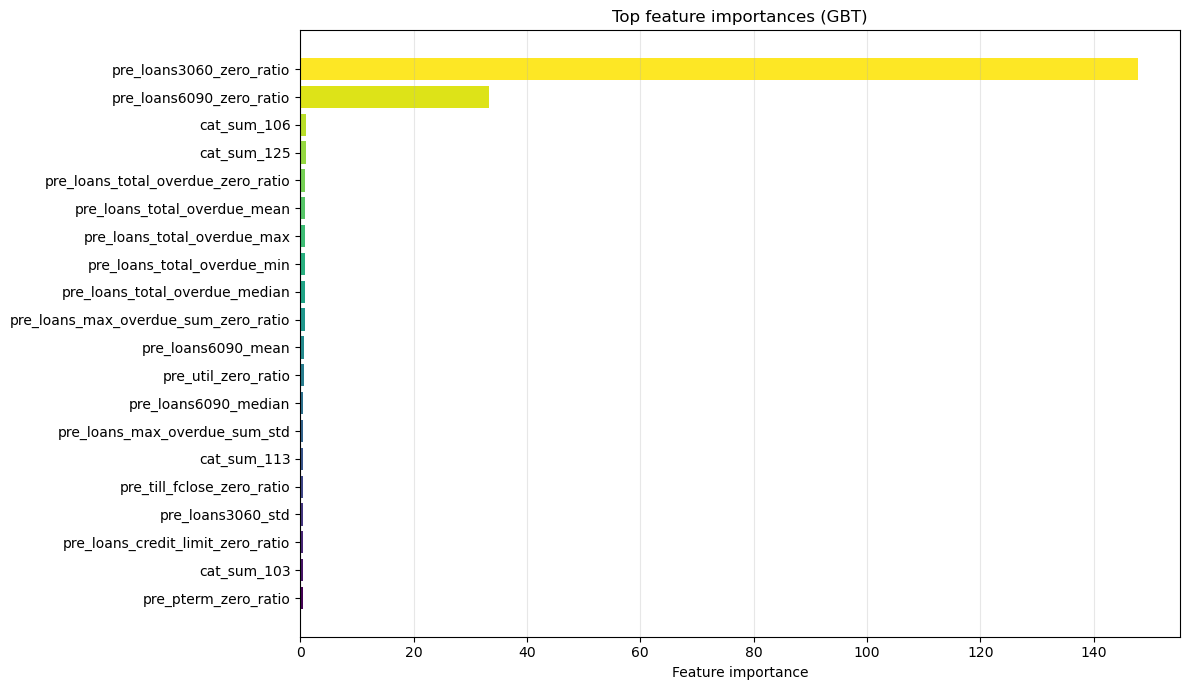


pre_loans3060_zero_ratio
  importance = 147.820951
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000

pre_loans6090_zero_ratio
  importance = 33.375308
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000

cat_sum_106
  importance = 1.057174
  class 0: mean=0.0000 std=0.0046
  class 1: mean=0.0000 std=0.0000

cat_sum_125
  importance = 1.027316
  class 0: mean=0.0001 std=0.0088
  class 1: mean=0.0000 std=0.0000

pre_loans_total_overdue_zero_ratio
  importance = 0.812741
  class 0: mean=1.0000 std=0.0000
  class 1: mean=1.0000 std=0.0000

pre_loans_total_overdue_mean
  importance = 0.812741
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000


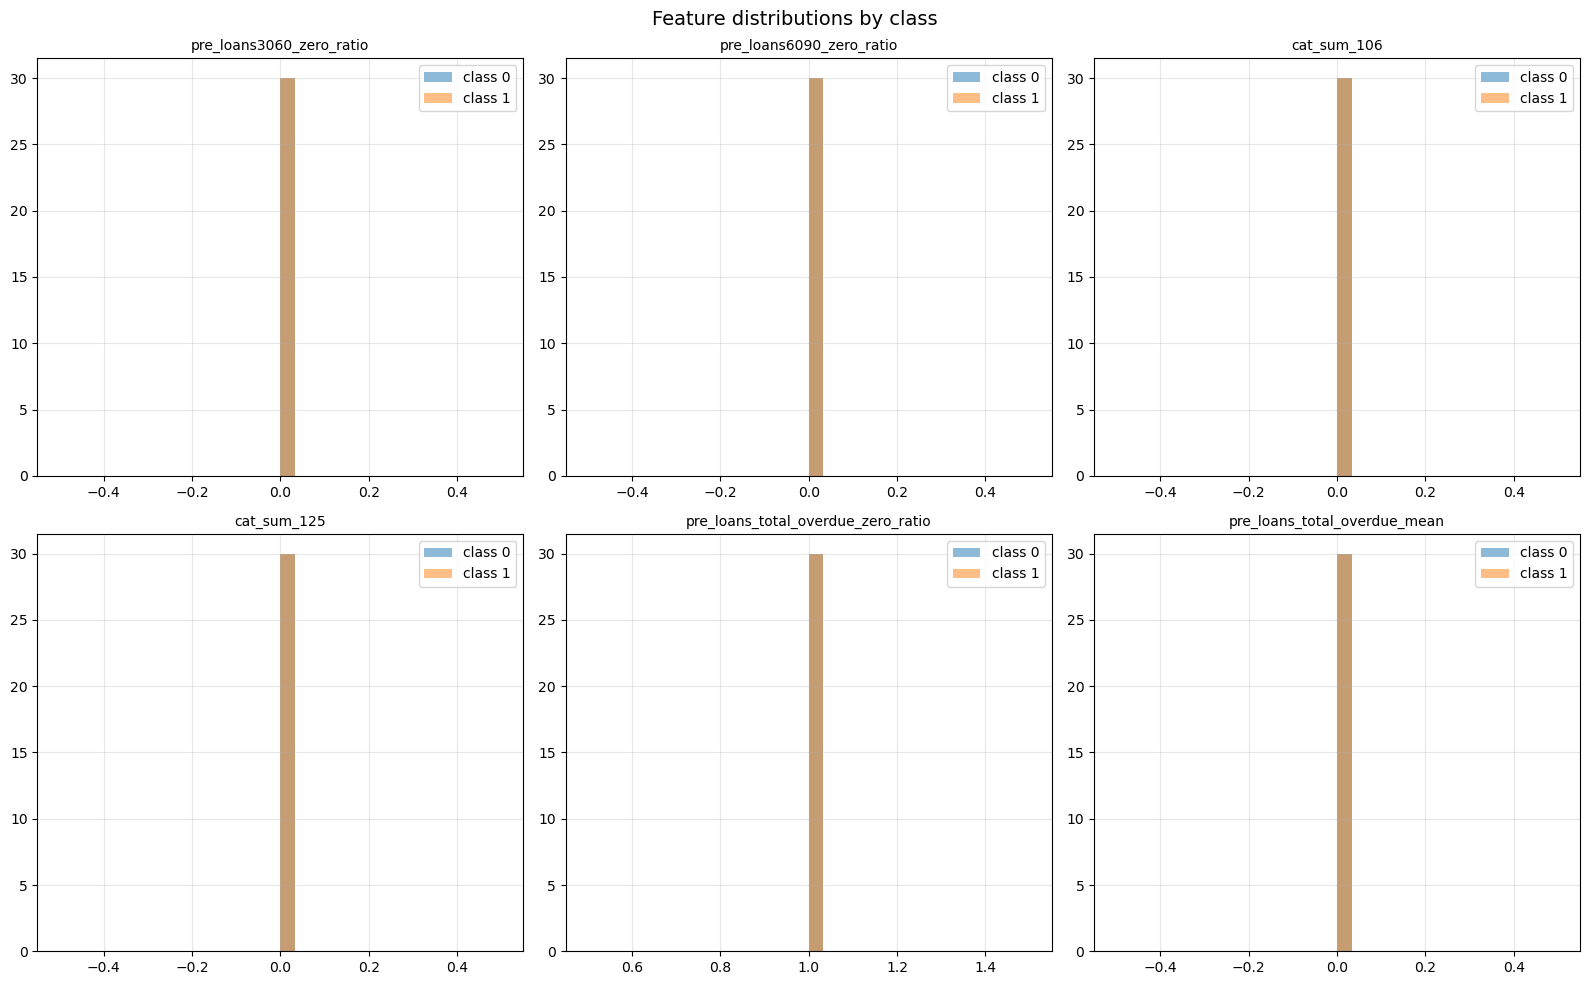


КОРРЕЛЯЦИЯ С TARGET:
pre_loans3060_zero_ratio                      corr=0.0000 importance=147.820951
pre_loans6090_zero_ratio                      corr=0.0000 importance=33.375308
cat_sum_106                                   corr=-0.0009 importance=1.057174
cat_sum_125                                   corr=-0.0017 importance=1.027316
pre_loans_total_overdue_zero_ratio            corr=0.0000 importance=0.812741
pre_loans_total_overdue_mean                  corr=0.0000 importance=0.812741
pre_loans_total_overdue_max                   corr=0.0000 importance=0.812741
pre_loans_total_overdue_min                   corr=0.0000 importance=0.812741
pre_loans_total_overdue_median                corr=0.0000 importance=0.812741
pre_loans_max_overdue_sum_zero_ratio          corr=0.0000 importance=0.812741


In [49]:
results = analyze_feature_dependencies_spark(
    train_features,
    model=model,
    feature_names=feature_names,
    sample_fraction=0.1,
    top_n=20
)

## Оценка RF

In [31]:
# Загрузка модели
model = load_model("models/rf_model")

# 4. Проверяем, что модель загрузилась
if model is not None:
    print(f"\nИнформация о модели:")
    print(f"  Тип: {type(model).__name__}")
    print(f"  UID: {model.uid}")

Загружаю модель из: models/rf_model
✓ Загружена модель: RandomForest

Информация о модели:
  Тип: RandomForestClassificationModel
  UID: RandomForestClassifier_54482e3f734d


In [32]:
metrics = evaluate_binary_model(
    model,
    train_features,
    label_col="flag"
)

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
AUC-ROC: 0.7045
Gini:    0.4089
--------------------------------------------------------------------------------
Accuracy:  0.6211
Precision: 0.0610
Recall:    0.6746
F1-score:  0.1119
--------------------------------------------------------------------------------
TP: 57,331 | FP: 881,960
FN: 27,655 | TN: 1,433,777


In [33]:
threshold_info = find_best_threshold(
    model,
    train_features,
    label_col="flag"
)

ЛУЧШИЙ ПОРОГ
Threshold: 0.620
Precision: 0.1000
Recall:    0.2569
F1-score:  0.1439


In [34]:
metrics = evaluate_binary_model(
    model,
    valid_features,
    label_col="flag"
)

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
AUC-ROC: 0.6981
Gini:    0.3962
--------------------------------------------------------------------------------
Accuracy:  0.6208
Precision: 0.0611
Recall:    0.6670
F1-score:  0.1119
--------------------------------------------------------------------------------
TP: 14,312 | FP: 220,077
FN: 7,144 | TN: 357,744


In [35]:
threshold_info = find_best_threshold(
    model,
    valid_features,
    label_col="flag"
)

ЛУЧШИЙ ПОРОГ
Threshold: 0.610
Precision: 0.0920
Recall:    0.2738
F1-score:  0.1378


In [36]:
top_feats = get_feature_importance(
    model,
    feature_names,
    top_n=20
)

for name, score in top_feats:
    print(f"{name:45s} {score:.6f}")

Feature importance method: tree_importance
cat_sum_6                                     0.040704
cat_sum_2                                     0.036088
cat_sum_118                                   0.033292
cat_sum_10                                    0.029255
cat_sum_20                                    0.028572
pre_loans_max_overdue_sum_min                 0.024004
cat_sum_61                                    0.023529
cat_sum_116                                   0.022273
cat_sum_12                                    0.020584
cat_sum_5                                     0.020080
cat_sum_77                                    0.020076
cat_sum_49                                    0.019766
cat_sum_53                                    0.019637
pre_util_min                                  0.019264
pre_loans_max_overdue_sum_std                 0.019047
cat_sum_9                                     0.017861
cat_sum_18                                    0.017672
cat_sum_73            

АНАЛИЗ ЗАВИСИМОСТИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ОТ ПРИЗНАКОВ (feature_names)
Importance method: abs_coefficients

ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ:
 1. pre_loans3060_zero_ratio                      147.820951
 2. pre_loans6090_zero_ratio                      33.375308
 3. cat_sum_106                                   1.057174
 4. cat_sum_125                                   1.027316
 5. pre_loans_total_overdue_zero_ratio            0.812741
 6. pre_loans_total_overdue_mean                  0.812741
 7. pre_loans_total_overdue_max                   0.812741
 8. pre_loans_total_overdue_min                   0.812741
 9. pre_loans_total_overdue_median                0.812741
10. pre_loans_max_overdue_sum_zero_ratio          0.812741
11. pre_loans6090_mean                            0.636010
12. pre_util_zero_ratio                           0.606943
13. pre_loans6090_median                          0.569090
14. pre_loans_max_overdue_sum_std                 0.568109
15. cat_sum_113                         

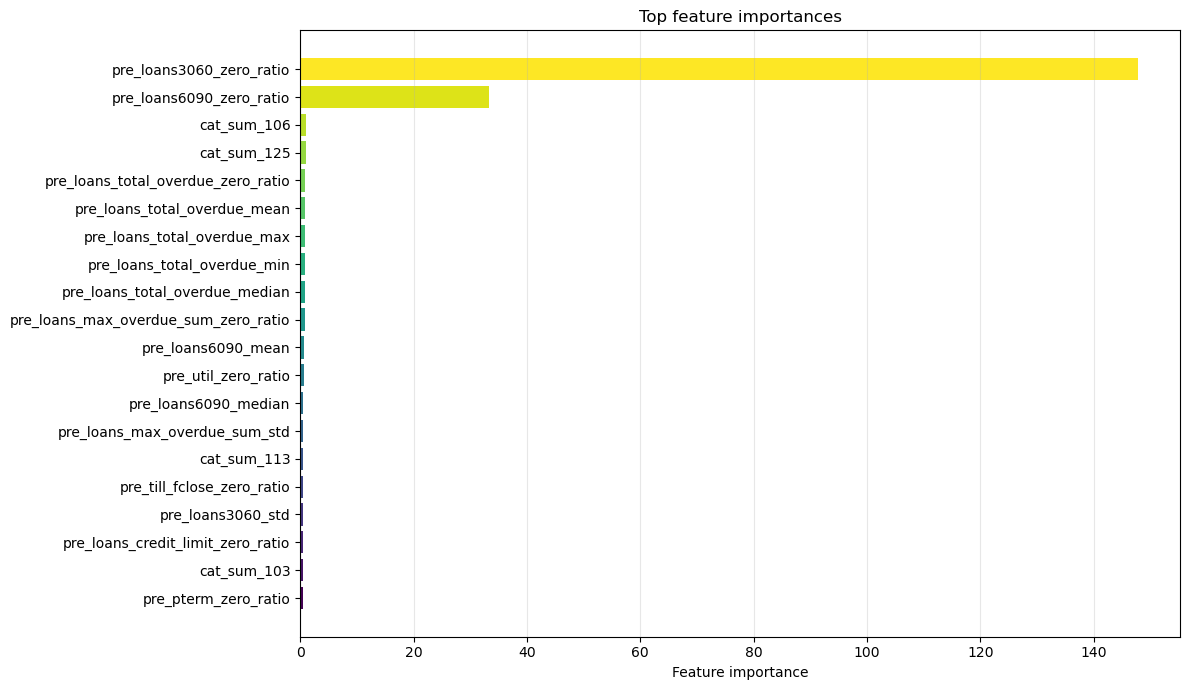


pre_loans3060_zero_ratio
  importance = 147.820951
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000

pre_loans6090_zero_ratio
  importance = 33.375308
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000

cat_sum_106
  importance = 1.057174
  class 0: mean=0.0000 std=0.0046
  class 1: mean=0.0000 std=0.0000

cat_sum_125
  importance = 1.027316
  class 0: mean=0.0001 std=0.0088
  class 1: mean=0.0000 std=0.0000

pre_loans_total_overdue_zero_ratio
  importance = 0.812741
  class 0: mean=1.0000 std=0.0000
  class 1: mean=1.0000 std=0.0000

pre_loans_total_overdue_mean
  importance = 0.812741
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000


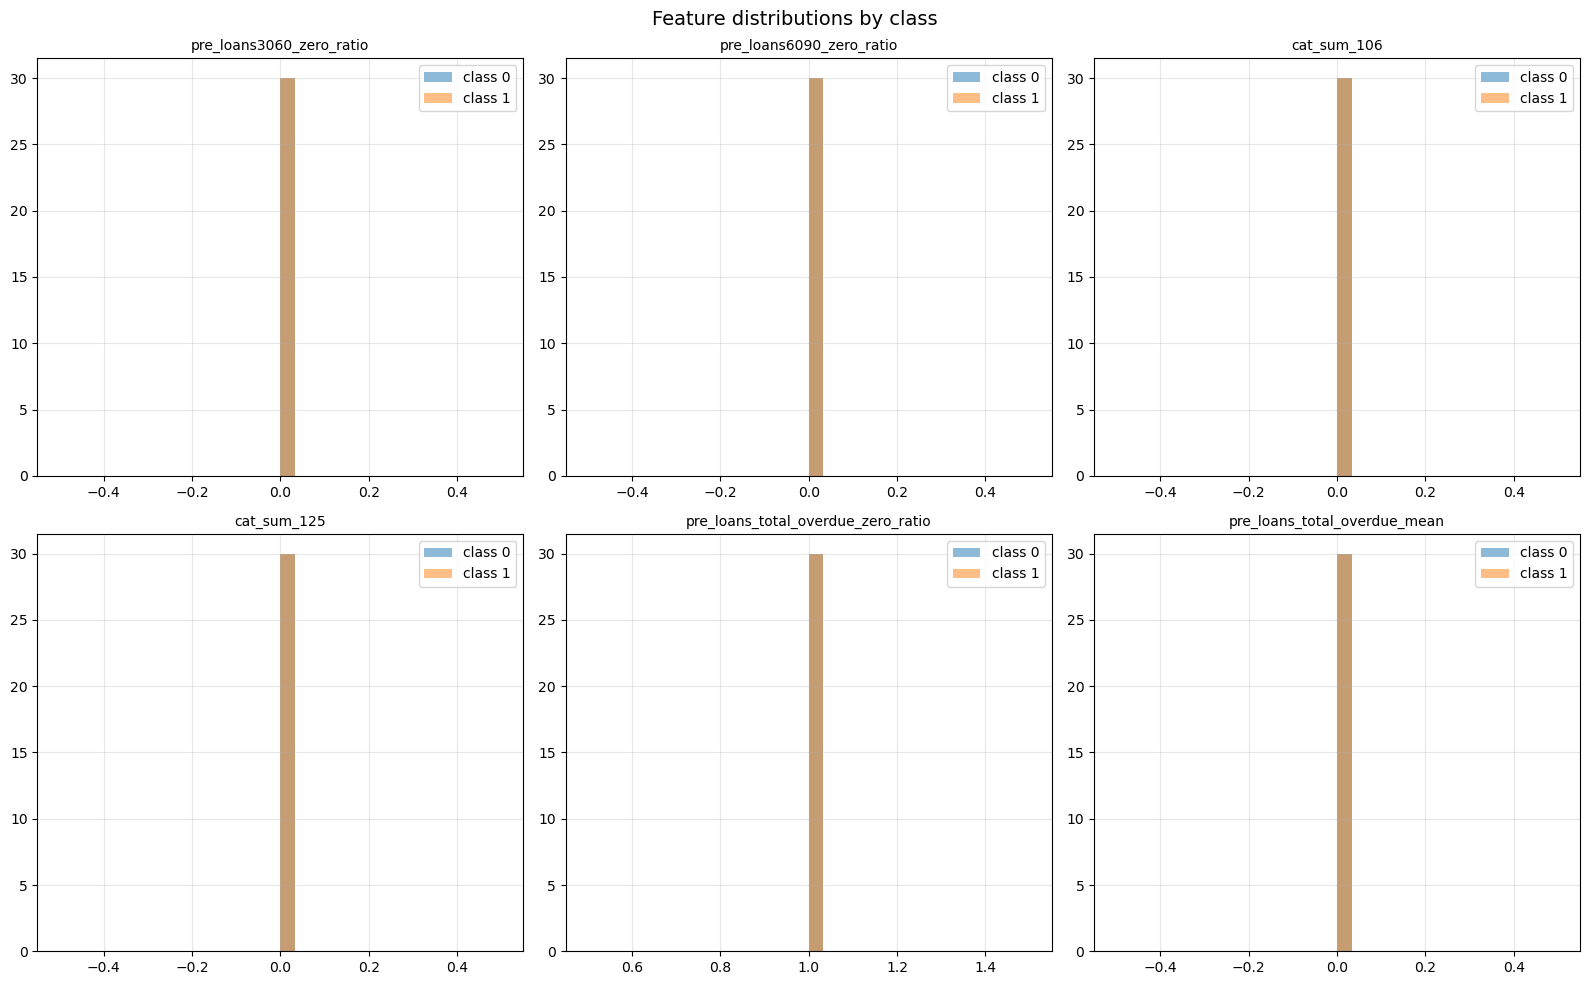


КОРРЕЛЯЦИЯ С TARGET:
pre_loans3060_zero_ratio                      corr=0.0000 importance=147.820951
pre_loans6090_zero_ratio                      corr=0.0000 importance=33.375308
cat_sum_106                                   corr=-0.0009 importance=1.057174
cat_sum_125                                   corr=-0.0017 importance=1.027316
pre_loans_total_overdue_zero_ratio            corr=0.0000 importance=0.812741
pre_loans_total_overdue_mean                  corr=0.0000 importance=0.812741
pre_loans_total_overdue_max                   corr=0.0000 importance=0.812741
pre_loans_total_overdue_min                   corr=0.0000 importance=0.812741
pre_loans_total_overdue_median                corr=0.0000 importance=0.812741
pre_loans_max_overdue_sum_zero_ratio          corr=0.0000 importance=0.812741


In [51]:
results = analyze_feature_dependencies_spark(
    train_features,
    model=model,
    feature_names=feature_names,
    sample_fraction=0.1,
    top_n=20
)

## Оценка LR

In [38]:
# Загрузка модели
model = load_model("models/lr_model")

# 4. Проверяем, что модель загрузилась
if model is not None:
    print(f"\nИнформация о модели:")
    print(f"  Тип: {type(model).__name__}")
    print(f"  UID: {model.uid}")

Загружаю модель из: models/lr_model
✓ Загружена модель: LogisticRegression

Информация о модели:
  Тип: LogisticRegressionModel
  UID: LogisticRegression_2edc8181a8d1


In [39]:
metrics = evaluate_binary_model(
    model,
    train_features,
    label_col="flag"
)

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
AUC-ROC: 0.7028
Gini:    0.4056
--------------------------------------------------------------------------------
Accuracy:  0.6189
Precision: 0.0614
Recall:    0.6834
F1-score:  0.1126
--------------------------------------------------------------------------------
TP: 58,076 | FP: 888,067
FN: 26,910 | TN: 1,427,670


In [40]:
threshold_info = find_best_threshold(
    model,
    train_features,
    label_col="flag"
)

ЛУЧШИЙ ПОРОГ
Threshold: 0.660
Precision: 0.0918
Recall:    0.2809
F1-score:  0.1383


In [41]:
metrics = evaluate_binary_model(
    model,
    valid_features,
    label_col="flag"
)

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
AUC-ROC: 0.7026
Gini:    0.4052
--------------------------------------------------------------------------------
Accuracy:  0.6198
Precision: 0.0623
Recall:    0.6845
F1-score:  0.1142
--------------------------------------------------------------------------------
TP: 14,686 | FP: 221,078
FN: 6,770 | TN: 356,743


In [42]:
threshold_info = find_best_threshold(
    model,
    valid_features,
    label_col="flag"
)

ЛУЧШИЙ ПОРОГ
Threshold: 0.640
Precision: 0.0888
Recall:    0.3298
F1-score:  0.1399


In [43]:
top_feats = get_feature_importance(
    model,
    feature_names,
    top_n=20
)

for name, score in top_feats:
    print(f"{name:45s} {score:.6f}")

Feature importance method: abs_coefficients
pre_loans3060_zero_ratio                      147.820951
pre_loans6090_zero_ratio                      33.375308
cat_sum_106                                   1.057174
cat_sum_125                                   1.027316
pre_loans_total_overdue_zero_ratio            0.812741
pre_loans_total_overdue_mean                  0.812741
pre_loans_total_overdue_max                   0.812741
pre_loans_total_overdue_min                   0.812741
pre_loans_total_overdue_median                0.812741
pre_loans_max_overdue_sum_zero_ratio          0.812741
pre_loans6090_mean                            0.636010
pre_util_zero_ratio                           0.606943
pre_loans6090_median                          0.569090
pre_loans_max_overdue_sum_std                 0.568109
cat_sum_113                                   0.562201
pre_till_fclose_zero_ratio                    0.519128
pre_loans3060_std                             0.425634
pre_loans_credit_l

АНАЛИЗ ЗАВИСИМОСТИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ОТ ПРИЗНАКОВ (feature_names)
Importance method: abs_coefficients

ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ:
 1. pre_loans3060_zero_ratio                      147.820951
 2. pre_loans6090_zero_ratio                      33.375308
 3. cat_sum_106                                   1.057174
 4. cat_sum_125                                   1.027316
 5. pre_loans_total_overdue_zero_ratio            0.812741
 6. pre_loans_total_overdue_mean                  0.812741
 7. pre_loans_total_overdue_max                   0.812741
 8. pre_loans_total_overdue_min                   0.812741
 9. pre_loans_total_overdue_median                0.812741
10. pre_loans_max_overdue_sum_zero_ratio          0.812741
11. pre_loans6090_mean                            0.636010
12. pre_util_zero_ratio                           0.606943
13. pre_loans6090_median                          0.569090
14. pre_loans_max_overdue_sum_std                 0.568109
15. cat_sum_113                         

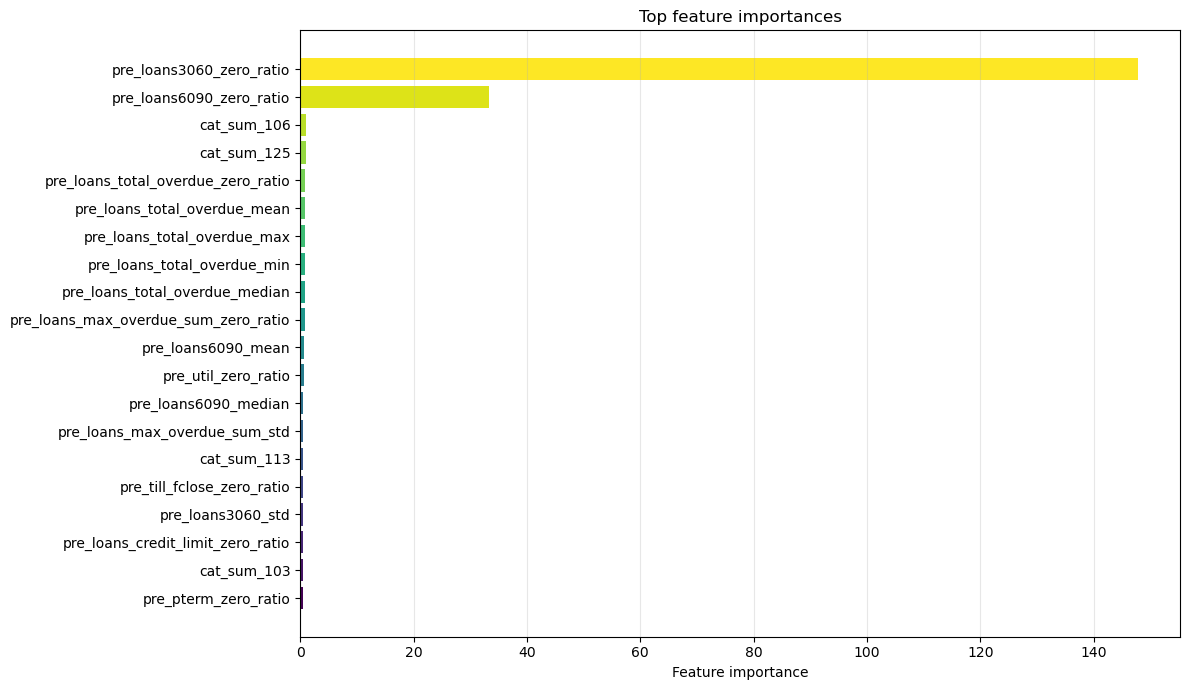


pre_loans3060_zero_ratio
  importance = 147.820951
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000

pre_loans6090_zero_ratio
  importance = 33.375308
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000

cat_sum_106
  importance = 1.057174
  class 0: mean=0.0000 std=0.0046
  class 1: mean=0.0000 std=0.0000

cat_sum_125
  importance = 1.027316
  class 0: mean=0.0001 std=0.0088
  class 1: mean=0.0000 std=0.0000

pre_loans_total_overdue_zero_ratio
  importance = 0.812741
  class 0: mean=1.0000 std=0.0000
  class 1: mean=1.0000 std=0.0000

pre_loans_total_overdue_mean
  importance = 0.812741
  class 0: mean=0.0000 std=0.0000
  class 1: mean=0.0000 std=0.0000


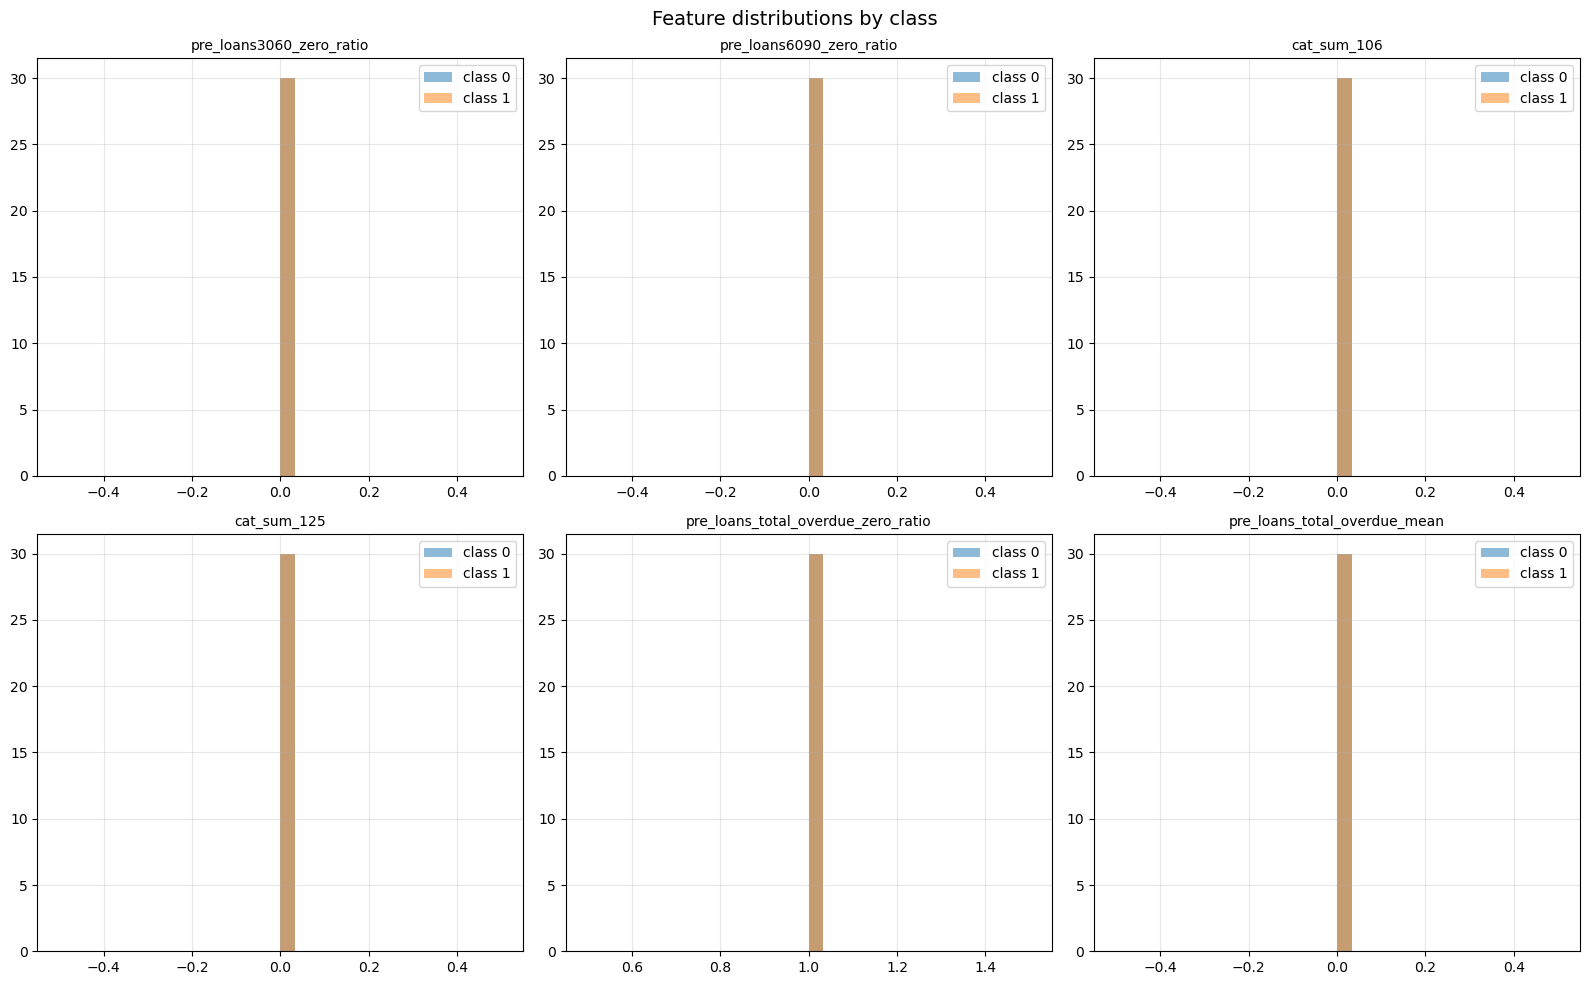


КОРРЕЛЯЦИЯ С TARGET:
pre_loans3060_zero_ratio                      corr=0.0000 importance=147.820951
pre_loans6090_zero_ratio                      corr=0.0000 importance=33.375308
cat_sum_106                                   corr=-0.0009 importance=1.057174
cat_sum_125                                   corr=-0.0017 importance=1.027316
pre_loans_total_overdue_zero_ratio            corr=0.0000 importance=0.812741
pre_loans_total_overdue_mean                  corr=0.0000 importance=0.812741
pre_loans_total_overdue_max                   corr=0.0000 importance=0.812741
pre_loans_total_overdue_min                   corr=0.0000 importance=0.812741
pre_loans_total_overdue_median                corr=0.0000 importance=0.812741
pre_loans_max_overdue_sum_zero_ratio          corr=0.0000 importance=0.812741


In [52]:
results = analyze_feature_dependencies_spark(
    train_features,
    model=model,
    feature_names=feature_names,
    sample_fraction=0.1,
    top_n=20
)

## Конец

Выключаем сессию `Apache Spark`.

In [53]:
spark.stop()